In [ ]:
# --- Part 1: Data Loading and Preparation (Corrected) ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv("final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")

Dataset loaded. Original shape: (3494, 30)
Removed 1 rows with missing 'Depression' values.
Data loading and preparation complete.


In [ ]:
# --- Part 2: Data Splitting and Feature Scaling ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [ ]:
# --- Part 3: Define Model "Varieties" (SVM) ---
from sklearn.svm import SVC

# changing the parameters to get the best rresults
svm_var1 = SVC(kernel='linear', C=1.0, random_state=42)
svm_var2 = SVC(kernel='rbf', C=1.0, random_state=42)
svm_var3 = SVC(kernel='rbf', C=10.0, random_state=42)

models = [svm_var1, svm_var2, svm_var3]
model_names = ['SVM (Linear, C=1)', 'SVM (RBF, C=1)', 'SVM (RBF, C=10)']

print("Defined 3 varieties for SVM.")

Defined 3 varieties for SVM.


In [ ]:
# --- Part 4: Train and Evaluate All 3 Varieties ---
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import time

results = {}

for model, name in zip(models, model_names):
    print(f"--- Training and Evaluating: {name} ---")
    print("Training... (This may take a few minutes for SVM)...")
    start_time = time.time()

    # 1. Modeltraining
    model.fit(X_train_scaled, y_train)

    end_time = time.time()
    print(f"Training finished in {end_time - start_time:.2f} seconds.")

    # 2. Test data - predictions
    y_pred = model.predict(X_test_scaled)

    # 3. Evaluation Matrix (Classification Report)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

    # 4. Evaluation Matrix (Confusion Matrix)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = f1
    print(f"Weighted F1-Score: {f1:.4f}")
    print("---------------------------------------------------\n")

--- Training and Evaluating: SVM (Linear, C=1) ---
Training... (This may take a few minutes for SVM)...
Training finished in 1.27 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.84      0.79      0.81       437
   Depression       0.86      0.89      0.87       611

     accuracy                           0.85      1048
    macro avg       0.85      0.84      0.84      1048
 weighted avg       0.85      0.85      0.85      1048

Confusion Matrix:
[[345  92]
 [ 66 545]]
Weighted F1-Score: 0.8485
---------------------------------------------------

--- Training and Evaluating: SVM (RBF, C=1) ---
Training... (This may take a few minutes for SVM)...
Training finished in 0.38 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.85      0.76      0.80       437
   Depression       0.84      0.90      0.87       611

     accuracy                           0.84      1048
  

--- Comparison of Member 3's Varieties ---
SVM (Linear, C=1): 0.8485
SVM (RBF, C=1): 0.8430
SVM (RBF, C=10): 0.8207

Conclusion: The best variety for SVM is 'SVM (Linear, C=1)'.

✅ Individual comparison chart saved to 'member_3_varieties_chart.png'
✅ Text summary saved to 'member_3_results.txt'


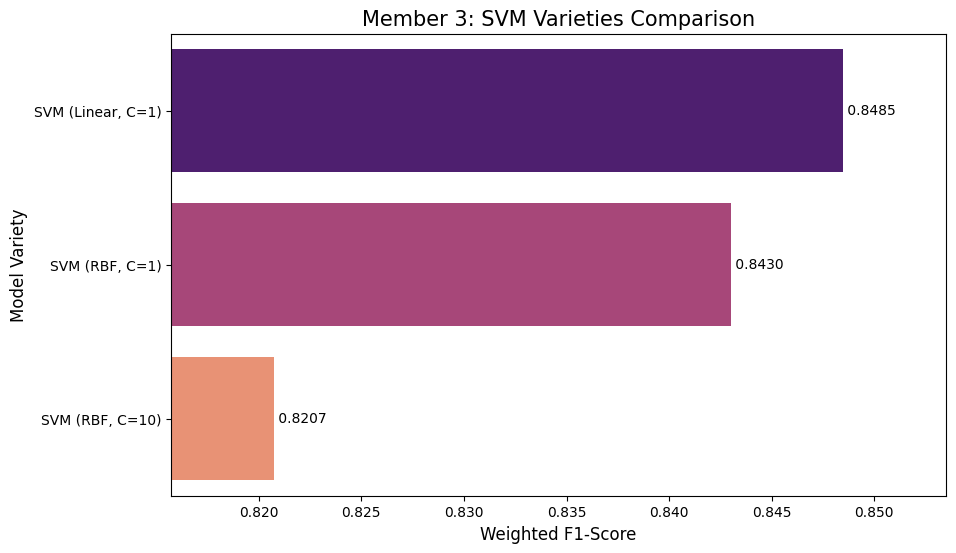

In [ ]:
# --- Part 5: Final Conclusion, Save Text & Create Chart (Member 3) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. finding the best variety
best_model_name = max(results, key=results.get)
best_f1_score = results[best_model_name]

print(f"--- Comparison of Member 3's Varieties ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

print(f"\nConclusion: The best variety for SVM is '{best_model_name}'.")

# --- ALUTH KOTASA: INDIVIDUAL GRAPHIC OUTPUT ---

# 2. Chart preparing
df_member3 = pd.DataFrame(list(results.items()), columns=['Variety', 'F1-Score'])

# 3. Bar chart preparing
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Variety', data=df_member3, palette='magma')
plt.title('Member 3: SVM Varieties Comparison', fontsize=15)
plt.xlabel('Weighted F1-Score', fontsize=12)
plt.ylabel('Model Variety', fontsize=12)
plt.xlim(min(df_member3['F1-Score']) - 0.005, max(df_member3['F1-Score']) + 0.005)

for index, value in enumerate(df_member3['F1-Score']):
    plt.text(value, index, f' {value:.4f}', va='center')

# 4. Chart eka image ekak widiyata save karanawa
chart_filename = "member_3_varieties_chart.png"
plt.savefig(chart_filename)
print(f"\n✅ Individual comparison chart saved to '{chart_filename}'")
# -----------------------------------------------

# 5. Text file eka hadala, eke content eka liyanawa
file_content = f"""
--- MEMBER 3: FINAL OPTIMUM RESULT ---
Model: Support Vector Machine (SVM)
Optimum Variety: {best_model_name}
Final Weighted F1-Score for Group Comparison: {best_f1_score:.4f}
--- Details of All Varieties Tested ---
"""
for name, score in results.items():
    file_content += f"{name}: {score:.4f}\n"

text_filename = "member_3_results.txt"
with open(text_filename, 'w') as f:
    f.write(file_content)

print(f"✅ Text summary saved to '{text_filename}'")